# Vertical nozzle-shock profiles

Preliminary one-dimensional cuts and ideal-hydrodynamic Rankine–Hugoniot estimates.

In [1]:
import importlib.util
import os
import sys
from pathlib import Path

os.environ.setdefault("MPLBACKEND", "Agg")
REPO = Path("/home/hey4/rich_tde")
sys.path.insert(0, str(REPO / "dev"))

import dev
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import richio
import richio.shockfinder as sf
from IPython.display import display
from dev import SNAPSHOT_TFB


## Choices

In [2]:
SELECTED_TFB = {"1e4": 1.0, "1e5": 1.0, "1e6": 1.0}
PROFILE_Z_RP = 0.06
PROFILE_RESOLUTION = 1024
SELECTION_HALF_WIDTH_RP = 0.08
SHOCK_SEARCH_Z_RP = 0.015
MIN_STATE_JUMP = 1.05
GAMMA_HYDRO = 5.0 / 3.0
GAMMA_SENSITIVITY = 4.0 / 3.0
WORKERS = 8
FIGSIZE = (12.0, 7.0)
OUTPUT_DIR = REPO / "data/processed/NozzleShockProfiles"

YZ_CACHE = {
    "1e4": REPO / "data/processed/NozzleYZSlices/1e4/grids/nozzle_yz_snap_0077_768.npz",
    "1e5": REPO / "data/processed/PresentationNozzleSlices/yz/grids/1e5/nozzle_yz_snap_0161_768_ycenter_m20Rsun_scale_1p2.npz",
    "1e6": REPO / "data/processed/PresentationNozzleSlices/yz/grids/1e6/nozzle_yz_snap_0850_768_ycenter_m80Rsun_scale_1p2.npz",
}


## Profiles

In [3]:
def load_script(name, path):
    spec = importlib.util.spec_from_file_location(name, path)
    module = importlib.util.module_from_spec(spec)
    sys.modules[name] = module
    spec.loader.exec_module(module)
    return module


yz_batch = load_script("nozzle_yz_slices_profile", REPO / "works/shock-tde/nozzle-yz-slices.py")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def compressed_y(cache_path):
    with np.load(cache_path) as data:
        y_rsun = np.asarray(data["y_rsun"])
        z_rsun = np.asarray(data["z_rsun"])
        density = np.asarray(data["density"])
        actual_tfb = float(data["time_tfb"])
    iz = int(np.argmin(np.abs(z_rsun)))
    iy = int(np.nanargmax(density[:, iz]))
    return float(y_rsun[iy]), actual_tfb


def profile_cache_path(run, snapnum):
    return OUTPUT_DIR / "profiles" / run / f"nozzle_z_profile_snap_{snapnum:04d}_{PROFILE_RESOLUTION}.npz"


def cache_complete(path):
    keys = {"z_rp", "density", "pressure", "temperature", "vz_kms", "internal_energy"}
    if not path.is_file():
        return False
    try:
        with np.load(path) as data:
            return keys.issubset(data.files) and data["z_rp"].shape == (PROFILE_RESOLUTION,)
    except (OSError, ValueError):
        return False


def build_profile(run, snapnum, snapshot_path, config, y_rsun, output):
    print(f"[{run}] loading snapshot {snapnum}", flush=True)
    snap = richio.load(str(snapshot_path))
    time = yz_batch.scalar_time(snap)
    x, y, z = snap.X, snap.Y, snap.Z
    if yz_batch.needs_reference_frame(run, Path(snapshot_path)):
        offset = dev.reference_frame_offset(
            t=time, Mbh=config.m_bh * richio.units.mscale,
            Mstar=config.m_star * richio.units.mscale,
            Rstar=config.r_star * richio.units.lscale, beta=1,
        )
        x, y = x + offset[0], y + offset[1]

    r_p = config.r_p * richio.units.lscale
    x_slice = yz_batch.SLICE_X_RP * r_p
    y_slice = y_rsun * richio.units.lscale
    z_half = PROFILE_Z_RP * r_p
    selection = (
        (np.abs(x - x_slice) < SELECTION_HALF_WIDTH_RP * r_p)
        & (np.abs(y - y_slice) < SELECTION_HALF_WIDTH_RP * r_p)
        & (np.abs(z) < 1.15 * z_half)
    )
    print(f"[{run}] selected {int(selection.sum()):,} nearby cells; extracting line profiles", flush=True)

    endpoints = ((x_slice, y_slice, -z_half), (x_slice, y_slice, z_half))
    fields = {
        "density": ("density", "g/cm**3"),
        "pressure": ("pressure", "dyn/cm**2"),
        "temperature": ("temperature", "K"),
        "vz_kms": ("vz", "km/s"),
        "internal_energy": ("internal_energy", "erg/g"),
    }
    arrays = {}
    coords = None
    for output_name, (field_name, unit) in fields.items():
        coords_i, _, values = snap.line_profile(
            field_name, *endpoints, res=PROFILE_RESOLUTION,
            X=x, Y=y, Z=z, selection=selection, workers=WORKERS,
        )
        if coords is None:
            coords = coords_i
        arrays[output_name] = np.asarray(values.to_value(unit), dtype="float64")
        print(f"[{run}] {field_name}", flush=True)

    arrays.update(
        z_rp=np.asarray(coords[:, 2] / r_p, dtype="float64"),
        y_rsun=np.asarray(y_rsun), x_rp=np.asarray(yz_batch.SLICE_X_RP),
        time_tfb=np.asarray(float(time / config.t_fb)),
    )
    output.parent.mkdir(parents=True, exist_ok=True)
    temporary = output.with_suffix(".tmp")
    with temporary.open("wb") as stream:
        np.savez_compressed(stream, **arrays)
    temporary.replace(output)


records = {}
for mode, run in enumerate(("1e4", "1e5", "1e6"), start=1):
    config = yz_batch.mode_settings(mode)
    snapnum, snapshot_path = SNAPSHOT_TFB(run, SELECTED_TFB[run])
    y_rsun, cached_tfb = compressed_y(YZ_CACHE[run])
    cache_path = profile_cache_path(run, snapnum)
    if not cache_complete(cache_path):
        build_profile(run, snapnum, snapshot_path, config, y_rsun, cache_path)
    records[run] = dict(
        run=run, config=config, snapnum=snapnum, snapshot_path=Path(snapshot_path),
        cache_path=cache_path, y_rsun=y_rsun, cached_tfb=cached_tfb,
    )
    print(f"{run}: snapshot {snapnum}, t/t_fb={cached_tfb:.3f}, y={y_rsun:.3f} R_sun")


1e4: snapshot 77, t/t_fb=0.999, y=-1.901 R_sun


/tmp/ipykernel_385622/43695791.py:98: UserWarning: Closest 1e5 snapshot is at 0.606 t_fb, which is 0.394 t_fb from the requested 1.000 t_fb
  snapnum, snapshot_path = SNAPSHOT_TFB(run, SELECTED_TFB[run])


1e5: snapshot 161, t/t_fb=0.606, y=-11.248 R_sun


1e6: snapshot 850, t/t_fb=1.002, y=5.732 R_sun


## Shock states and Mach estimates

In [4]:
def load_profile(path):
    with np.load(path) as data:
        profile = {name: np.asarray(data[name]) for name in data.files}
    rho, pressure = profile["density"], profile["pressure"]
    internal_energy = profile["internal_energy"]
    gamma_eff = 1.0 + pressure / (rho * internal_energy)
    sound_speed_kms = np.sqrt(gamma_eff * pressure / rho) / 1.0e5
    profile["gamma_eff"] = gamma_eff
    profile["sound_speed_kms"] = sound_speed_kms
    profile["mach_proxy"] = np.abs(profile["vz_kms"]) / sound_speed_kms
    return profile


def safe_mach(inverter, ratio, gamma):
    if not np.isfinite(ratio) or ratio < 1.0:
        return np.nan
    with np.errstate(invalid="ignore", divide="ignore"):
        value = float(inverter(ratio, gamma=gamma))
    return value if np.isfinite(value) and value >= 1.0 else np.nan


def shock_pair(profile, side):
    z = profile["z_rp"]
    rho = profile["density"]
    pressure = profile["pressure"]
    center = int(np.argmin(np.abs(z)))
    step = 1 if side == "upper" else -1
    inner = center
    while 0 <= inner + step < len(z) and abs(z[inner + step]) <= SHOCK_SEARCH_Z_RP:
        outer = inner + step
        rho_jump = rho[inner] / rho[outer]
        pressure_jump = pressure[inner] / pressure[outer]
        if rho_jump >= MIN_STATE_JUMP and pressure_jump >= MIN_STATE_JUMP:
            return outer, inner
        inner = outer
    return None


def state_row(run, side, profile, gamma):
    pair = shock_pair(profile, side)
    if pair is None:
        return dict(run=run, side=side, gamma=gamma, reliable=False)
    pre, post = pair
    ratios = {
        "rho": profile["density"][post] / profile["density"][pre],
        "P": profile["pressure"][post] / profile["pressure"][pre],
        "T": profile["temperature"][post] / profile["temperature"][pre],
    }
    return dict(
        run=run, side=side, gamma=gamma, reliable=True, pre_idx=pre, post_idx=post,
        z_pre=profile["z_rp"][pre], z_post=profile["z_rp"][post],
        rho_pre=profile["density"][pre], rho_post=profile["density"][post], R_rho=ratios["rho"],
        P_pre=profile["pressure"][pre], P_post=profile["pressure"][post], R_P=ratios["P"],
        T_pre=profile["temperature"][pre], T_post=profile["temperature"][post], R_T=ratios["T"],
        gamma_eff_pre=profile["gamma_eff"][pre], gamma_eff_post=profile["gamma_eff"][post],
        M_direct=profile["mach_proxy"][pre],
        M_rho=safe_mach(sf.rho2rho1M, ratios["rho"], gamma),
        M_P=safe_mach(sf.P2P1M, ratios["P"], gamma),
        M_T=safe_mach(sf.T2T1M, ratios["T"], gamma),
    )


profiles = {run: load_profile(record["cache_path"]) for run, record in records.items()}
rows = [state_row(run, side, profiles[run], GAMMA_HYDRO) for run in records for side in ("upper", "lower")]
states = pd.DataFrame(rows)
display(states[["run", "side", "z_pre", "z_post", "R_rho", "R_P", "R_T", "M_rho", "M_P", "M_T", "M_direct", "gamma_eff_pre", "gamma_eff_post"]])

rows_43 = [state_row(run, side, profiles[run], GAMMA_SENSITIVITY) for run in records for side in ("upper", "lower")]
states_43 = pd.DataFrame(rows_43)
print(f"Mach sensitivity for gamma={GAMMA_SENSITIVITY:.3f}")
display(states_43[["run", "side", "M_rho", "M_P", "M_T"]])


,run,side,z_pre,z_post,R_rho,R_P,R_T,M_rho,M_P,M_T,M_direct,gamma_eff_pre,gamma_eff_post
0,1e4,upper,0.000645,0.000528,1.449488,1.482293,1.022632,1.305733,1.177215,1.102674,0.639160,1.635608,1.636264
1,1e4,lower,-0.001232,-0.001114,1.384788,1.416841,1.023147,1.260372,1.154761,1.103205,1.631139,1.635593,1.636264
2,1e5,upper,0.000059,-0.000059,1.434748,8.571450,5.974184,1.295339,2.656532,4.074742,10.034096,1.561348,1.646368
3,1e5,lower,-0.002874,-0.002757,5.107121,3.813146,0.746633,NaN,1.802919,NaN,8.535908,1.651393,1.646368
4,1e6,upper,0.000528,0.000411,2.060400,2.073812,1.006509,1.785173,1.363470,1.086054,8.196898,1.518265,1.519012
5,1e6,lower,-0.007214,-0.007097,3.865524,3.909399,1.011351,9.286277,1.824149,1.091040,11.366012,1.517710,1.519012


Mach sensitivity for gamma=1.333


,run,side,M_rho,M_P,M_T
0,1e4,upper,1.251747,1.192479,1.343241
1,1e4,lower,1.216422,1.168219,1.344194
2,1e5,upper,1.243716,2.761344,5.633871
3,1e5,lower,4.023483,1.860511,NaN
4,1e6,upper,1.581996,1.392690,1.313287
5,1e6,lower,2.720178,1.883009,1.322297


## Plots

1e4: snapshot 77, t/t_fb=0.999, y=-1.901 R_sun


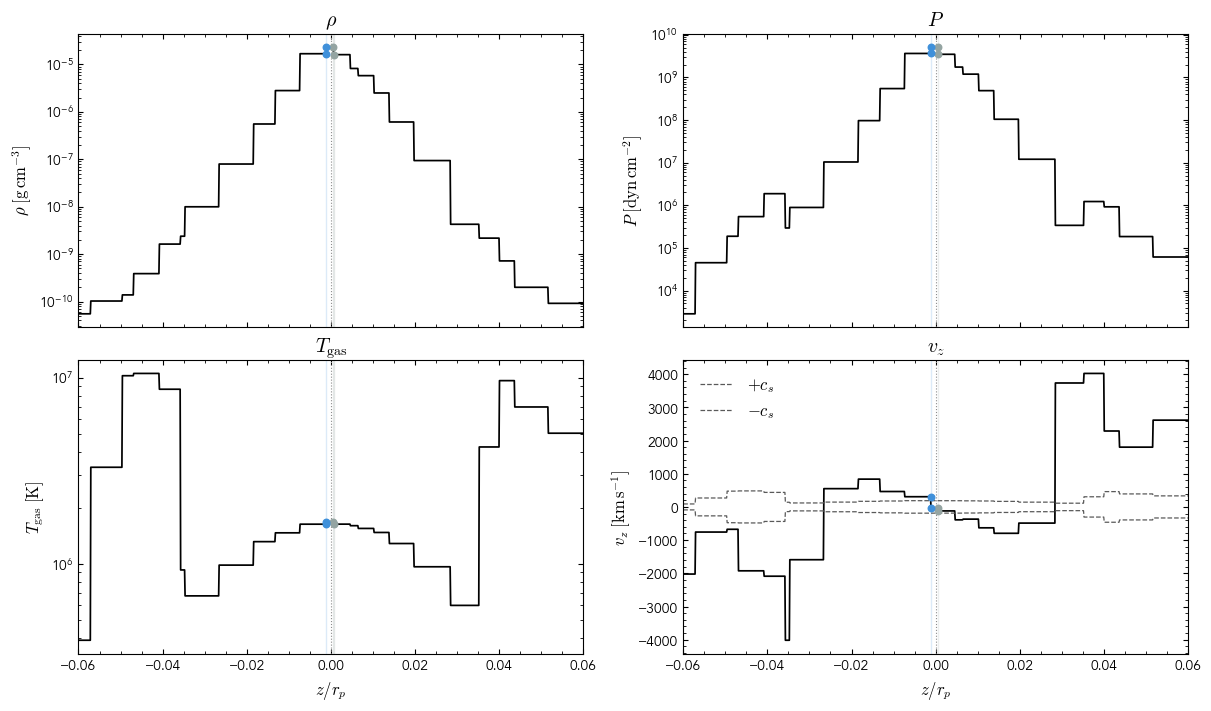

1e5: snapshot 161, t/t_fb=0.606, y=-11.248 R_sun


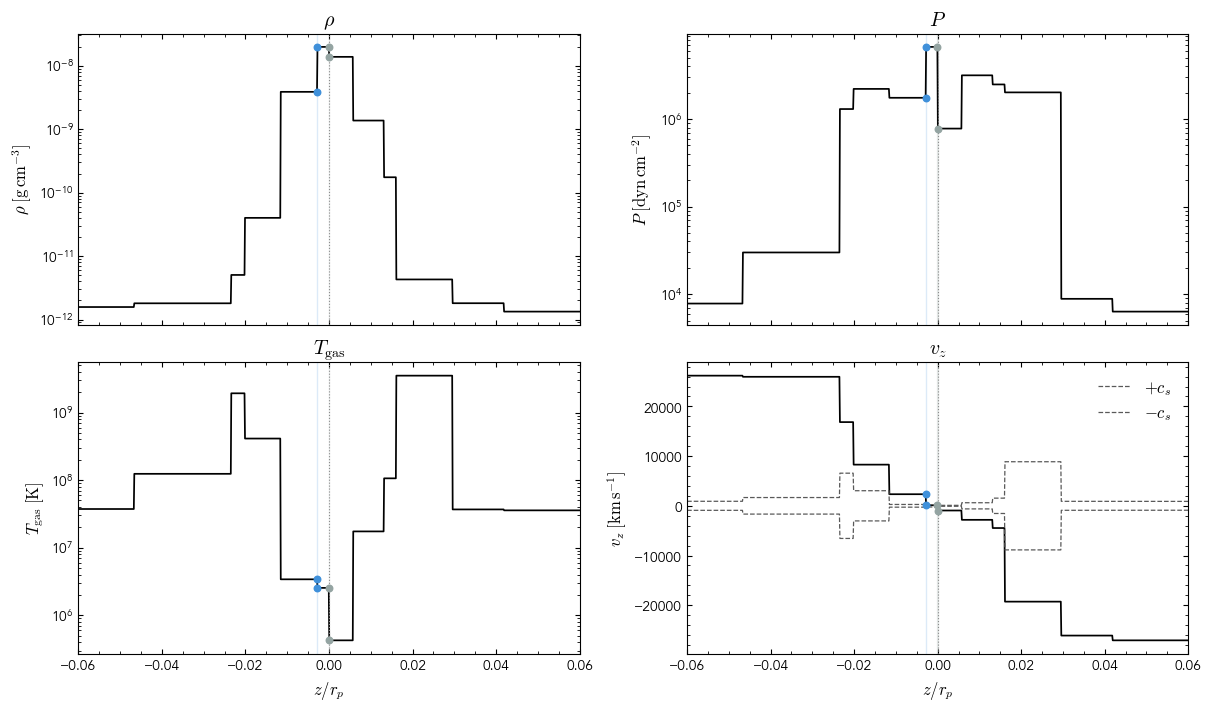

1e6: snapshot 850, t/t_fb=1.002, y=5.732 R_sun


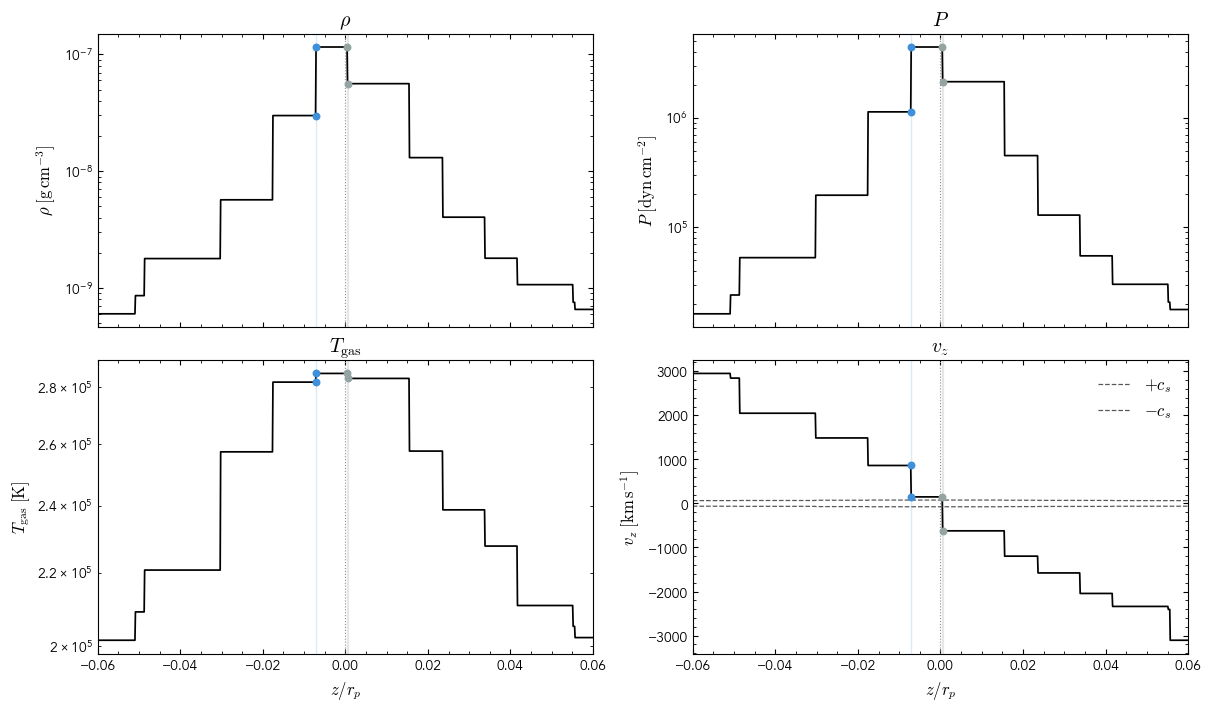

In [5]:
def plot_profile(run, profile, run_states):
    z = profile["z_rp"]
    fig, axes = plt.subplots(2, 2, figsize=FIGSIZE, sharex=True, layout="constrained")
    panels = (
        ("density", r"$\rho$", r"$\rho\;[\mathrm{g\,cm^{-3}}]$", True),
        ("pressure", r"$P$", r"$P\;[\mathrm{dyn\,cm^{-2}}]$", True),
        ("temperature", r"$T_\mathrm{gas}$", r"$T_\mathrm{gas}\;[\mathrm{K}]$", True),
        ("vz_kms", r"$v_z$", r"$v_z\;[\mathrm{km\,s^{-1}}]$", False),
    )
    side_colors = {"upper": "C3", "lower": "C0"}
    for ax, (field, title, ylabel, use_log) in zip(axes.flat, panels):
        ax.plot(z, profile[field], color="black", lw=1.25)
        if use_log:
            ax.set_yscale("log")
        ax.set_title(title)
        ax.set_ylabel(ylabel)
        ax.axvline(0.0, color="0.55", ls=":", lw=0.8)
        for _, row in run_states.iterrows():
            if not row.get("reliable", False):
                continue
            color = side_colors[row["side"]]
            ax.axvspan(min(row["z_pre"], row["z_post"]), max(row["z_pre"], row["z_post"]), color=color, alpha=0.18)
            ax.scatter([row["z_pre"], row["z_post"]], [profile[field][int(row["pre_idx"])], profile[field][int(row["post_idx"])]], color=color, s=22, zorder=4)
    axes[1, 1].plot(z, profile["sound_speed_kms"], color="0.35", ls="--", lw=0.9, label=r"$+c_s$")
    axes[1, 1].plot(z, -profile["sound_speed_kms"], color="0.35", ls="--", lw=0.9, label=r"$-c_s$")
    axes[1, 1].legend(frameon=False, loc="best")
    for ax in axes[-1]:
        ax.set_xlabel(r"$z/r_p$")
    for ax in axes.flat:
        ax.set_xlim(-PROFILE_Z_RP, PROFILE_Z_RP)
    return fig


for run, record in records.items():
    print(f"{run}: snapshot {record['snapnum']}, t/t_fb={record['cached_tfb']:.3f}, y={record['y_rsun']:.3f} R_sun")
    display(plot_profile(run, profiles[run], states[states.run == run]))
    plt.close()


The pre/post pair on each side is the first adjacent profile-cell pair moving outward from the compressed core with at least a 5% inward rise in both density and pressure, searched within $|z|<0.015r_p$. The jump estimates assume a stationary, planar ideal-hydrodynamic shock. The displayed direct Mach value is only the lab-frame proxy $|v_z|/c_s$; it is not corrected for shock motion. Radiation pressure, radiative precursors, repeated cell sampling, and multiple shock transitions can invalidate agreement between the three Rankine–Hugoniot inversions.